# Naive baseline

For this, we assume we have access to training data sampled sparsely from the underling conditional temporal process (x, y, t). 

We then want to train a NN $\Phi(x, t) = y$, in a supervised manner. Then, we can sample from this naive surrogate at arbitrary t, with condition x, to get arbitrary temporal distribution

In [1]:
import time
import torch
from torch import nn, Tensor
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
from sklearn.datasets import make_moons
import numpy as np
from scipy.stats import vonmises as scipy_vonmises
from scipy.stats import lognorm as scipy_lognorm
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [4]:
torch.manual_seed(0)

# Naive Cancer RL

In [5]:
def rl_data_gen():
    """
    Loads the rl reward weighting dataset.
    """

    data = torch.load("../NLOT/data/reward_weighting_data_0_10.pt")
    data = data.to(device)
    return data

In [6]:
rl_data = rl_data_gen()
rl_data = rl_data[:,:1000]
rl_training_data = rl_data[[0,5,10]]

In [7]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [8]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [11]:
# Prepare RL training data
def prepare_rl_training_data():
    """
    Prepare RL data for training according to requirements:
    - Input 'x': first 2 entries from timepoint 0
    - Input 't': desired timepoint (0, 5, or 10) 
    - Input 'cond': remaining 7 entries from timepoint 0
    - Target: first 2 entries from the corresponding row at target timepoint
    """
    
    # rl_training_data shape: [3, 1000, 9] - timepoints [0,5,10], 1000 samples, 9 features
    timepoint_0_data = rl_training_data[0]  # [1000, 9]
    timepoint_5_data = rl_training_data[1]  # [1000, 9] 
    timepoint_10_data = rl_training_data[2]  # [1000, 9]
    
    # Extract components from timepoint 0
    x_base = timepoint_0_data[:, :2]  # First 2 entries [1000, 2]
    cond_base = timepoint_0_data[:, 2:]  # Remaining 7 entries [1000, 7]
    
    # Create training samples for each target timepoint
    all_x = []
    all_t = []
    all_cond = []
    all_targets = []
    
    # Target timepoint 0 (identity mapping)
    all_x.append(x_base)
    all_t.append(torch.zeros(1000, 1, device=device))  # t=0
    all_cond.append(cond_base)
    all_targets.append(timepoint_0_data[:, :2])  # First 2 entries of timepoint 0
    
    # Target timepoint 5
    all_x.append(x_base)
    all_t.append(torch.full((1000, 1), 5.0, device=device))  # t=5
    all_cond.append(cond_base)
    all_targets.append(timepoint_5_data[:, :2])  # First 2 entries of timepoint 5
    
    # Target timepoint 10
    all_x.append(x_base)
    all_t.append(torch.full((1000, 1), 10.0, device=device))  # t=10
    all_cond.append(cond_base)
    all_targets.append(timepoint_10_data[:, :2])  # First 2 entries of timepoint 10
    
    # Concatenate all training data
    train_x = torch.cat(all_x, dim=0)  # [3000, 2]
    train_t = torch.cat(all_t, dim=0)  # [3000, 1]
    train_cond = torch.cat(all_cond, dim=0)  # [3000, 7]
    train_targets = torch.cat(all_targets, dim=0)  # [3000, 2]
    
    return {
        'x': train_x,
        't': train_t, 
        'cond': train_cond,
        'targets': train_targets
    }

# Prepare the training data
rl_train_data = prepare_rl_training_data()
print(f"Training data shapes:")
print(f"x: {rl_train_data['x'].shape}")
print(f"t: {rl_train_data['t'].shape}")
print(f"cond: {rl_train_data['cond'].shape}")
print(f"targets: {rl_train_data['targets'].shape}")

Training data shapes:
x: torch.Size([3000, 2])
t: torch.Size([3000, 1])
cond: torch.Size([3000, 7])
targets: torch.Size([3000, 2])


In [23]:
# Training function for RL model with early stopping
def train_rl_model(model, train_data, num_epochs=1000, learning_rate=1e-3, batch_size=256, 
                   patience=100, min_delta=1e-6, validation_split=0.2):
    """
    Train the RL neural network model with early stopping.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    x_data = train_data['x']
    t_data = train_data['t']
    cond_data = train_data['cond']
    target_data = train_data['targets']
    
    num_samples = x_data.shape[0]
    
    # Split data into train and validation
    val_size = int(num_samples * validation_split)
    train_size = num_samples - val_size
    
    # Random split
    indices = torch.randperm(num_samples)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Training data
    x_train = x_data[train_indices]
    t_train = t_data[train_indices]
    cond_train = cond_data[train_indices]
    target_train = target_data[train_indices]
    
    # Validation data
    x_val = x_data[val_indices]
    t_val = t_data[val_indices]
    cond_val = cond_data[val_indices]
    target_val = target_data[val_indices]
    
    train_losses = []
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"Training for up to {num_epochs} epochs with batch size {batch_size}")
    print(f"Training samples: {train_size}, Validation samples: {val_size}")
    print(f"Early stopping: patience={patience}, min_delta={min_delta}")
    val_losses = []
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"Training for up to {num_epochs} epochs with batch size {batch_size}")
    print(f"Training samples: {train_size}, Validation samples: {val_size}")
    print(f"Early stopping: patience={patience}, min_delta={min_delta}")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_train_batches = 0
        
        # Shuffle training data
        perm = torch.randperm(train_size)
        x_shuffled = x_train[perm]
        t_shuffled = t_train[perm]
        cond_shuffled = cond_train[perm]
        target_shuffled = target_train[perm]
        
        # Mini-batch training
        for i in range(0, train_size, batch_size):
            batch_x = x_shuffled[i:i+batch_size]
            batch_t = t_shuffled[i:i+batch_size]
            batch_cond = cond_shuffled[i:i+batch_size]
            batch_targets = target_shuffled[i:i+batch_size]
            
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_x, batch_t, batch_cond)
            loss = criterion(predictions, batch_targets)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            num_train_batches += 1
        
        avg_train_loss = epoch_train_loss / num_train_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val, t_val, cond_val)
            val_loss = criterion(val_predictions, target_val).item()
            val_losses.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model state
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 100 == 0 or patience_counter >= patience:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, "
                  f"Val Loss: {val_loss:.6f}, Patience: {patience_counter}/{patience}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.6f}")
            # Restore best model
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
                print("Restored best model weights")
            break
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'epochs_trained': epoch + 1
    }

In [31]:
for i in range(5):
    rl_model = MLP(
        input_dim=2,     # First 2 entries from timepoint 0
        time_dim=1,      # Timepoint (0, 5, or 10)
        hidden_dim=128,  # Hidden layer size
        cond_dim=7       # Remaining 7 entries from timepoint 0
    ).to(device)

    print(f"Starting RL model {i} training...")
    training_results = train_rl_model(
        model=rl_model,
        train_data=rl_train_data,
        num_epochs=10000,
        learning_rate=1e-3,
        batch_size=256,
        patience=250,        # Wait 250 epochs for improvement
        min_delta=1e-6,      # Minimum improvement threshold
        validation_split=0.1 # Use 10% of data for validation
    )

    print(f"Model {i} training completed:")
    print(f"  Epochs trained: {training_results['epochs_trained']}")
    print(f"  Best validation loss: {training_results['best_val_loss']:.6f}")
    print(f"  Final train loss: {training_results['train_losses'][-1]:.6f}")
    print("-" * 60)

    torch.save(rl_model.state_dict(), f'naive_model_{i}.pt')

Starting RL model 0 training...
Training for up to 10000 epochs with batch size 256
Training samples: 2700, Validation samples: 300
Early stopping: patience=250, min_delta=1e-06
Training for up to 10000 epochs with batch size 256
Training samples: 2700, Validation samples: 300
Early stopping: patience=250, min_delta=1e-06
------------------------------------------------------------


Epoch [100/10000], Train Loss: 0.199264, Val Loss: 0.197547, Patience: 3/250
Epoch [200/10000], Train Loss: 0.189364, Val Loss: 0.187505, Patience: 5/250
Epoch [200/10000], Train Loss: 0.189364, Val Loss: 0.187505, Patience: 5/250
Epoch [300/10000], Train Loss: 0.188169, Val Loss: 0.177135, Patience: 21/250
Epoch [300/10000], Train Loss: 0.188169, Val Loss: 0.177135, Patience: 21/250
Epoch [400/10000], Train Loss: 0.186547, Val Loss: 0.185972, Patience: 121/250
Epoch [400/10000], Train Loss: 0.186547, Val Loss: 0.185972, Patience: 121/250
Epoch [500/10000], Train Loss: 0.185174, Val Loss: 0.179098, Patience: 221/250
Epoch [500/10000], Train Loss: 0.185174, Val Loss: 0.179098, Patience: 221/250
Epoch [529/10000], Train Loss: 0.182151, Val Loss: 0.181088, Patience: 250/250
Early stopping triggered at epoch 529
Best validation loss: 0.175302
Restored best model weights
Model 0 training completed:
  Epochs trained: 529
  Best validation loss: 0.175302
  Final train loss: 0.182151
---------

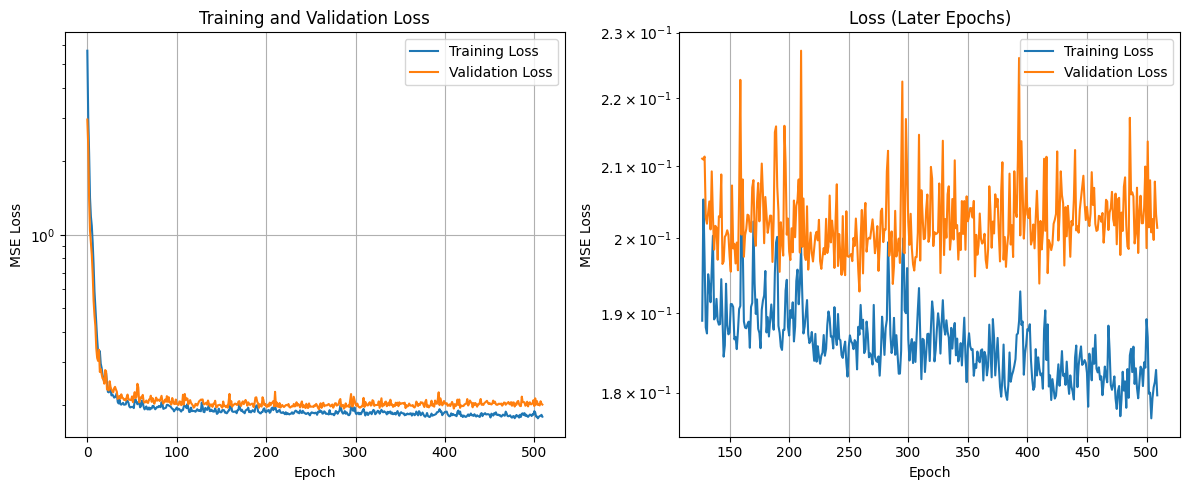

Training completed after 510 epochs
Best validation loss: 0.192827
Final training loss: 0.179669
Final validation loss: 0.201379


In [32]:
# Plot training and validation losses
plt.figure(figsize=(12, 5))

# Plot 1: Training loss
plt.subplot(1, 2, 1)
plt.plot(training_results['train_losses'], label='Training Loss')
plt.plot(training_results['val_losses'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

# Plot 2: Zoomed in view of later epochs
plt.subplot(1, 2, 2)
start_epoch = max(0, len(training_results['train_losses']) // 4)  # Start from 1/4 through training
plt.plot(range(start_epoch, len(training_results['train_losses'])), 
         training_results['train_losses'][start_epoch:], label='Training Loss')
plt.plot(range(start_epoch, len(training_results['val_losses'])), 
         training_results['val_losses'][start_epoch:], label='Validation Loss')
plt.title('Loss (Later Epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Training completed after {training_results['epochs_trained']} epochs")
print(f"Best validation loss: {training_results['best_val_loss']:.6f}")
print(f"Final training loss: {training_results['train_losses'][-1]:.6f}")
print(f"Final validation loss: {training_results['val_losses'][-1]:.6f}")

In [33]:
# Test the trained model
def test_rl_model(model, test_indices=[0, 1, 2], target_timepoints=[0, 5, 10]):
    """
    Test the trained model on specific samples
    """
    model.eval()
    
    with torch.no_grad():
        # Get test data from timepoint 0
        test_x = rl_training_data[0][test_indices, :2]  # First 2 entries
        test_cond = rl_training_data[0][test_indices, 2:]  # Remaining 7 entries
        
        print("Testing model predictions:")
        print("=" * 50)
        
        for i, idx in enumerate(test_indices):
            print(f"\nSample {idx}:")
            print(f"Input x (from t=0): {test_x[i].cpu().numpy()}")
            print(f"Conditioning: {test_cond[i].cpu().numpy()}")
            
            for target_t in target_timepoints:
                # Predict
                t_tensor = torch.tensor([[float(target_t)]], device=device)
                x_input = test_x[i:i+1]
                cond_input = test_cond[i:i+1]
                
                prediction = model(x_input, t_tensor, cond_input)
                
                # Get ground truth
                timepoint_idx = {0: 0, 5: 1, 10: 2}[target_t]
                ground_truth = rl_training_data[timepoint_idx][idx, :2]
                
                pred_np = prediction[0].cpu().numpy()
                gt_np = ground_truth.cpu().numpy()
                error = torch.norm(prediction[0] - ground_truth).item()
                
                print(f"  t={target_t}: Predicted=[{pred_np[0]:.4f}, {pred_np[1]:.4f}], "
                      f"Ground Truth=[{gt_np[0]:.4f}, {gt_np[1]:.4f}], "
                      f"Error={error:.4f}")

# Test the model
test_rl_model(rl_model)

Testing model predictions:

Sample 0:
Input x (from t=0): [0.        2.9635572]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[-0.0053, 2.8816], Ground Truth=[0.0000, 2.9636], Error=0.0822
  t=5: Predicted=[6.1160, 0.5795], Ground Truth=[5.8026, 1.1765], Error=0.6742
  t=10: Predicted=[9.8397, 2.0948], Ground Truth=[9.7287, 3.0308], Error=0.9426

Sample 1:
Input x (from t=0): [0.        2.0878088]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[0.0011, 2.0484], Ground Truth=[0.0000, 2.0878], Error=0.0395
  t=5: Predicted=[6.1501, 0.3825], Ground Truth=[6.2944, 0.4304], Error=0.1520
  t=10: Predicted=[9.8367, 2.0079], Ground Truth=[10.0000, 1.9903], Error=0.1643

Sample 2:
Input x (from t=0): [0.        1.9325614]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[0.0058, 1.9083], Ground Truth=[0.0000, 

In [34]:
# Comprehensive evaluation
def evaluate_model_performance(model):
    """
    Evaluate model performance on all data
    """
    model.eval()
    
    with torch.no_grad():
        # Test on all timepoints
        x_input = rl_train_data['x']
        t_input = rl_train_data['t']
        cond_input = rl_train_data['cond']
        targets = rl_train_data['targets']
        
        # Get predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Calculate MSE for each timepoint
        mse_per_timepoint = {}
        for t_val in [0, 5, 10]:
            mask = (t_input.squeeze() == t_val)
            if mask.sum() > 0:
                pred_t = predictions[mask]
                target_t = targets[mask]
                mse_t = torch.mean((pred_t - target_t) ** 2).item()
                mse_per_timepoint[t_val] = mse_t
                print(f"MSE for timepoint {t_val}: {mse_t:.6f}")
        
        # Overall MSE
        overall_mse = torch.mean((predictions - targets) ** 2).item()
        print(f"Overall MSE: {overall_mse:.6f}")
        
        return mse_per_timepoint, overall_mse

# Evaluate the model
print("Model Performance Evaluation:")
print("=" * 40)
timepoint_mse, overall_mse = evaluate_model_performance(rl_model)

Model Performance Evaluation:
MSE for timepoint 0: 0.003533
MSE for timepoint 5: 0.289992
MSE for timepoint 10: 0.245241
Overall MSE: 0.179589


In [35]:
# Plotting function for model outputs
def plot_model_outputs_at_timepoint(model, target_timepoint, num_samples=None, figsize=(12, 8)):
    """
    Plot the outputs of the trained NN casting all entries at timepoint 0 to an arbitrary target timepoint
    
    Args:
        model: Trained MLP model
        target_timepoint: Target timepoint to cast to (can be any float value)
        num_samples: Number of samples to plot (None for all 1000 samples)
        figsize: Figure size for the plot
    """
    model.eval()
    
    if num_samples is None:
        num_samples = rl_training_data[0].shape[0]  # Use all samples
    else:
        num_samples = min(num_samples, rl_training_data[0].shape[0])
    
    with torch.no_grad():
        # Get input data from timepoint 0
        x_input = rl_training_data[0][:num_samples, :2]  # First 2 entries [N, 2]
        cond_input = rl_training_data[0][:num_samples, 2:]  # Remaining 7 entries [N, 7]
        
        # Create time tensor for target timepoint
        t_input = torch.full((num_samples, 1), float(target_timepoint), device=device)
        
        # Get model predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Convert to numpy for plotting
        predictions_np = predictions.cpu().numpy()
        
        # Create single plot of predicted distribution
        plt.figure(figsize=(8, 6))
        plt.scatter(predictions_np[:, 0], predictions_np[:, 1], alpha=0.6, s=20, c='red')
        plt.xlabel('Predicted x[0]')
        plt.ylabel('Predicted x[1]')
        plt.title(f'Predicted Distribution at t={target_timepoint}')
        plt.xlim(0,10)
        plt.ylim(0,8)
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Print some statistics
        print(f"Statistics for {num_samples} samples at t={target_timepoint}:")
        print(f"Predicted range - x[0]: [{predictions_np[:, 0].min():.3f}, {predictions_np[:, 0].max():.3f}], "
              f"x[1]: [{predictions_np[:, 1].min():.3f}, {predictions_np[:, 1].max():.3f}]")
        
        return predictions_np

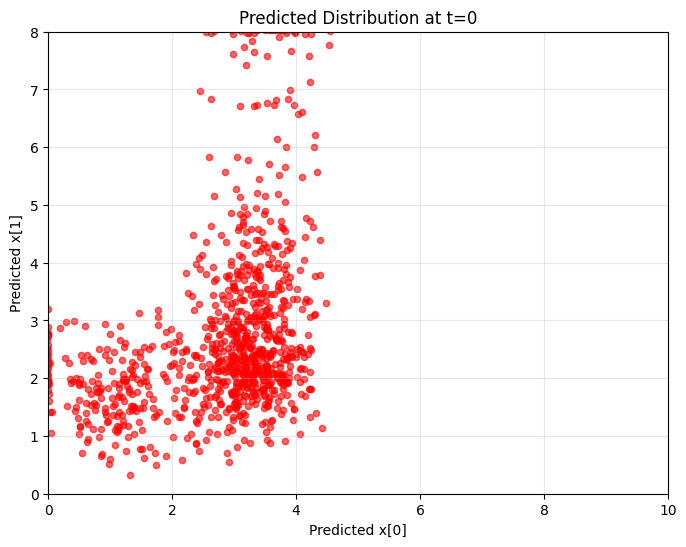

Statistics for 1000 samples at t=0:
Predicted range - x[0]: [-0.016, 4.543], x[1]: [0.327, 8.152]


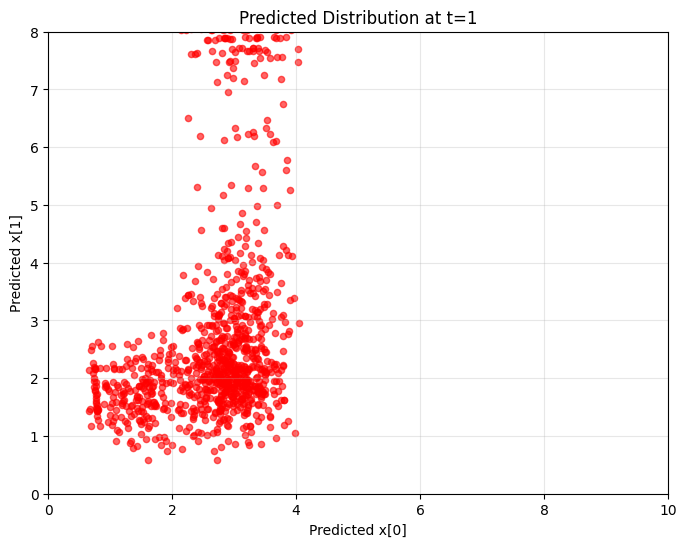

Statistics for 1000 samples at t=1:
Predicted range - x[0]: [0.651, 4.052], x[1]: [0.581, 8.172]


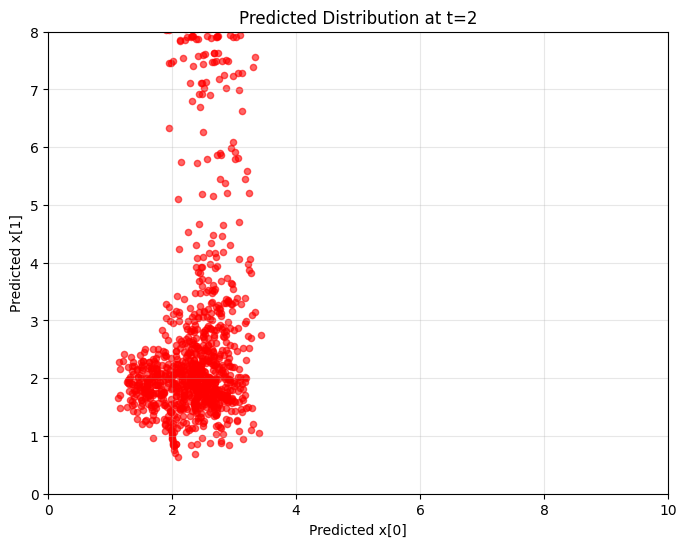

Statistics for 1000 samples at t=2:
Predicted range - x[0]: [1.127, 3.431], x[1]: [0.639, 8.194]


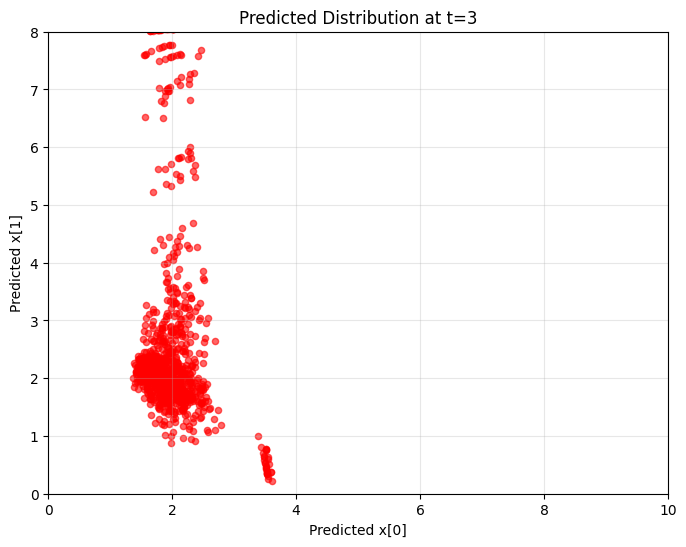

Statistics for 1000 samples at t=3:
Predicted range - x[0]: [1.363, 3.608], x[1]: [0.225, 8.194]


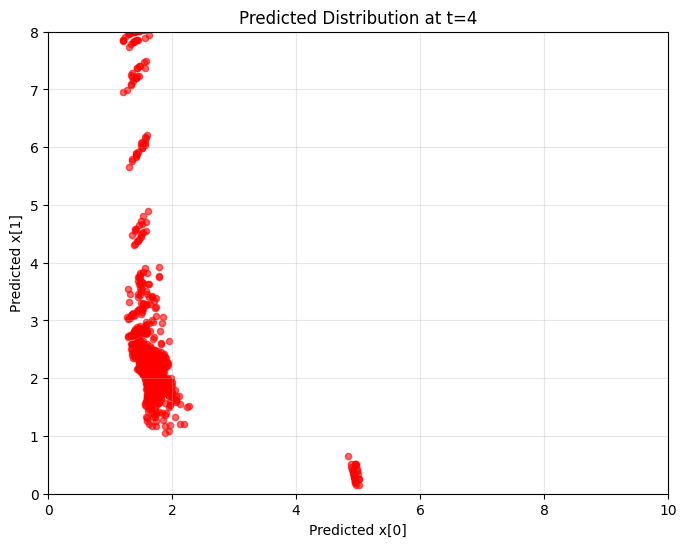

Statistics for 1000 samples at t=4:
Predicted range - x[0]: [1.203, 5.017], x[1]: [0.154, 8.196]


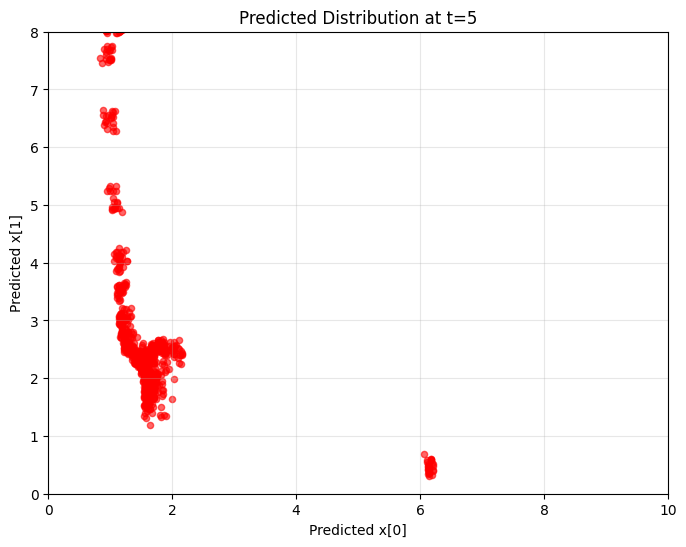

Statistics for 1000 samples at t=5:
Predicted range - x[0]: [0.829, 6.207], x[1]: [0.312, 8.205]


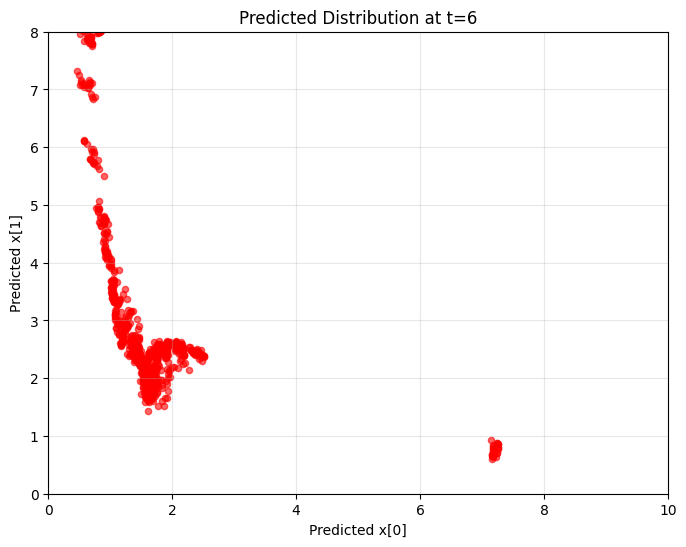

Statistics for 1000 samples at t=6:
Predicted range - x[0]: [0.471, 7.255], x[1]: [0.606, 8.187]


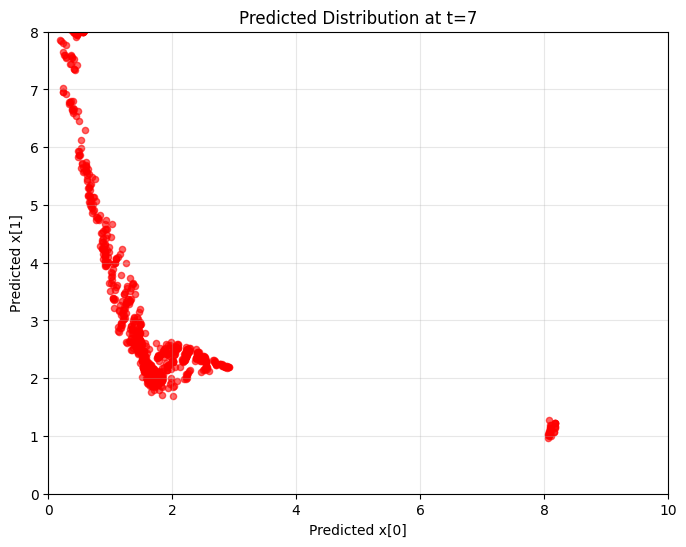

Statistics for 1000 samples at t=7:
Predicted range - x[0]: [0.185, 8.180], x[1]: [0.972, 8.176]


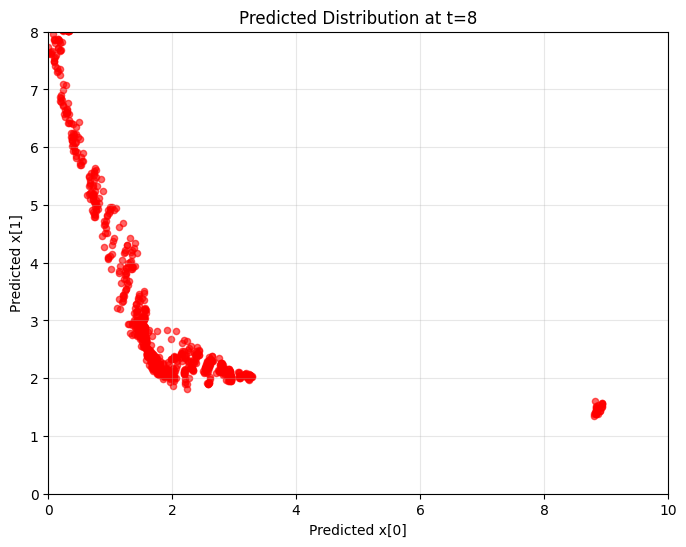

Statistics for 1000 samples at t=8:
Predicted range - x[0]: [-0.010, 8.929], x[1]: [1.341, 8.168]


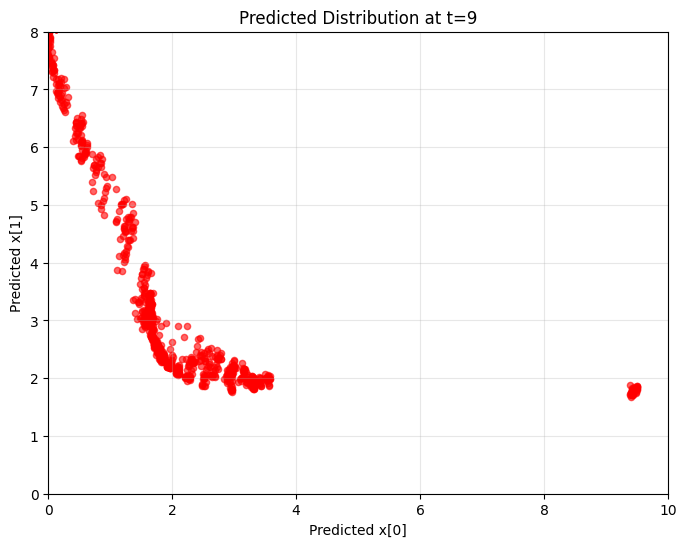

Statistics for 1000 samples at t=9:
Predicted range - x[0]: [-0.103, 9.494], x[1]: [1.679, 8.239]


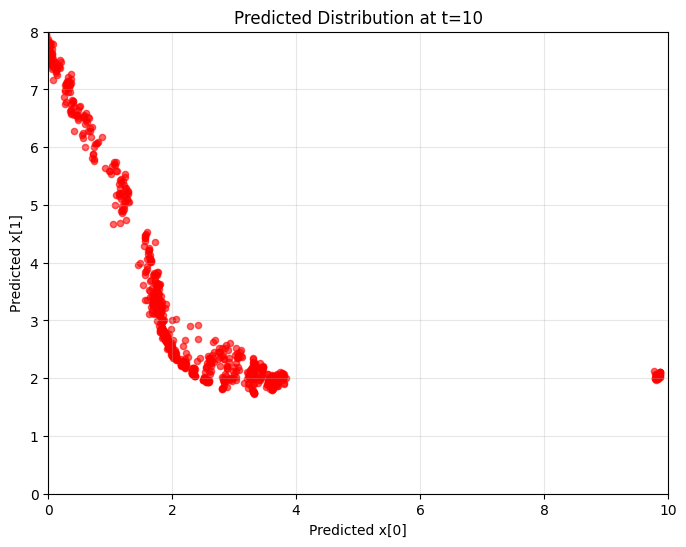

Statistics for 1000 samples at t=10:
Predicted range - x[0]: [-0.107, 9.873], x[1]: [1.721, 8.244]


array([[9.839652 , 2.0947688],
       [9.836651 , 2.0078743],
       [9.827294 , 1.991351 ],
       ...,
       [1.7572172, 3.1886775],
       [1.7681105, 3.2818098],
       [1.7345742, 3.1372318]], dtype=float32)

In [36]:
plot_model_outputs_at_timepoint(rl_model, target_timepoint=0, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=1, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=2, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=3, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=4, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=5, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=6, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=7, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=8, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=9, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=10, num_samples=1000)

Comparing predictions vs ground truth:


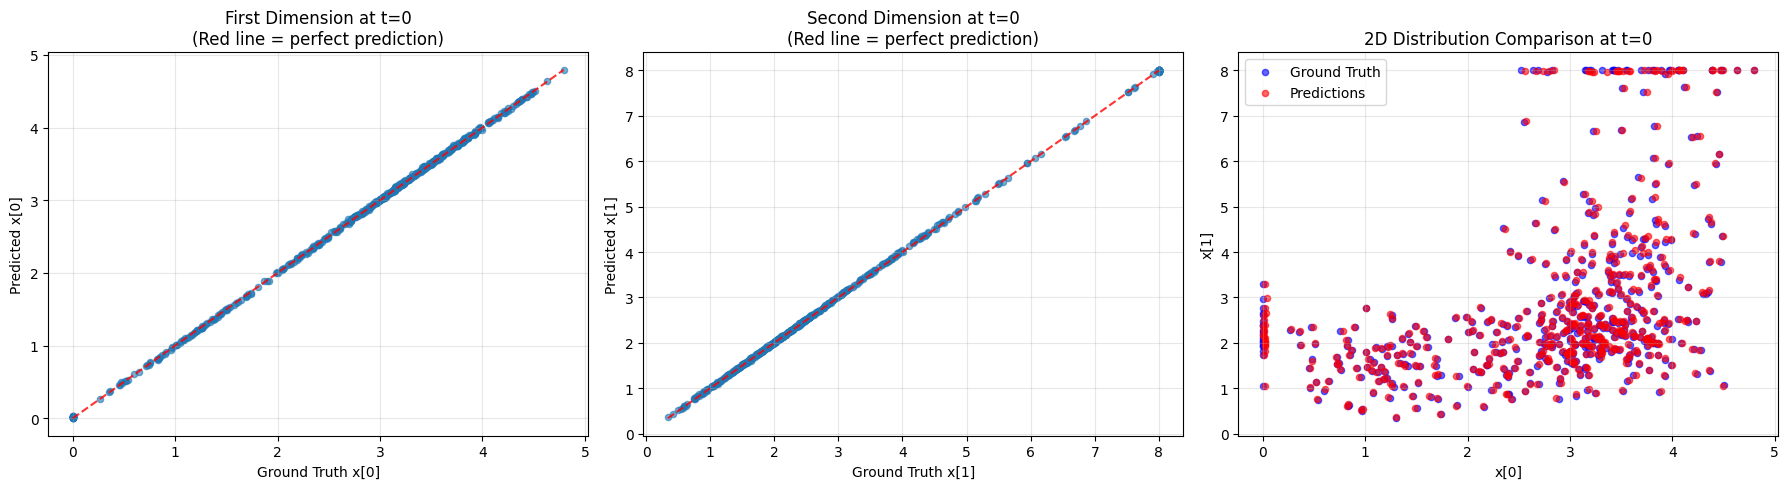

Error metrics for t=0:
MSE: 0.000323
MAE: 0.014095


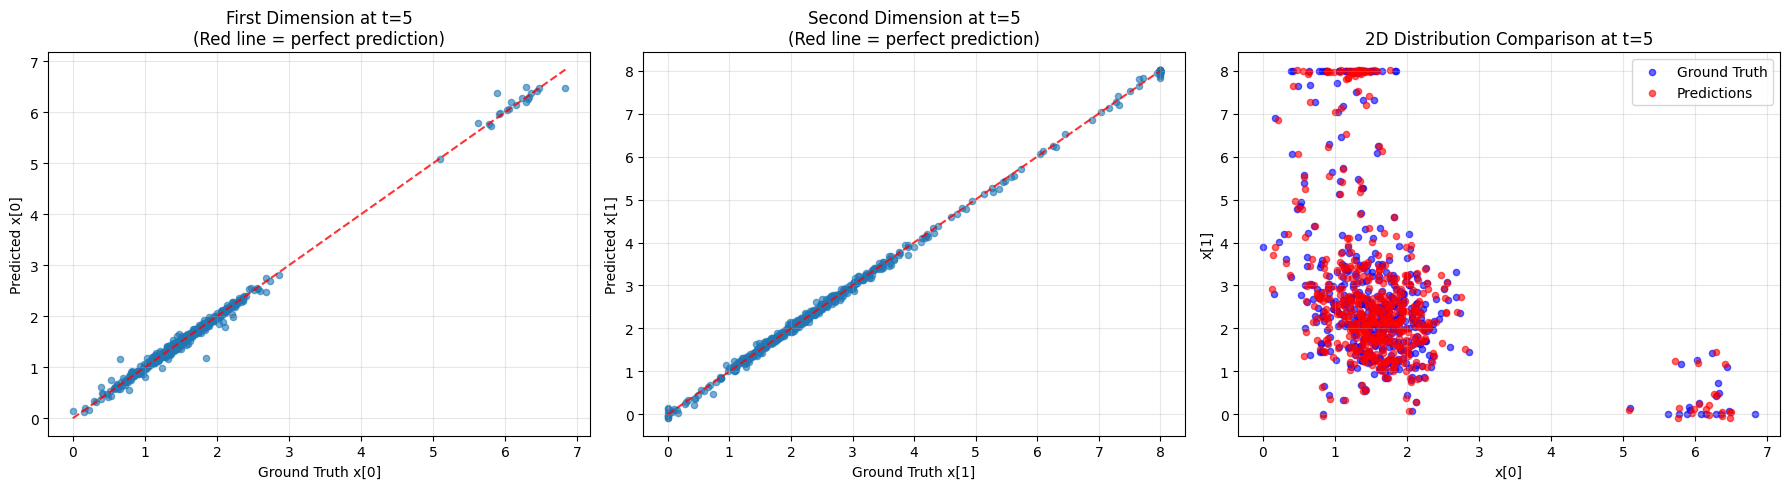

Error metrics for t=5:
MSE: 0.004661
MAE: 0.045190


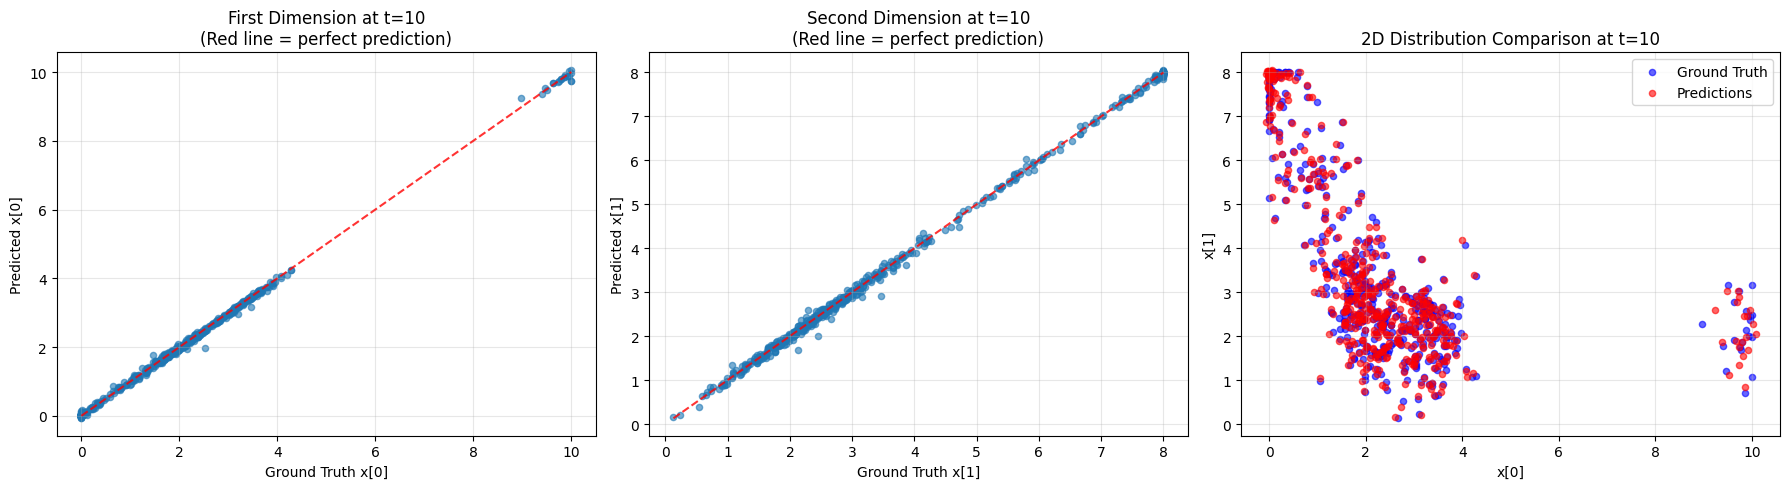

Error metrics for t=10:
MSE: 0.004936
MAE: 0.047024


In [19]:
# Comparison function: Model predictions vs Ground Truth
def compare_predictions_vs_ground_truth(model, target_timepoint, num_samples=500):
    """
    Compare model predictions with ground truth at training timepoints
    """
    # Map timepoint to index
    timepoint_to_idx = {0: 0, 5: 1, 10: 2}
    
    if target_timepoint not in timepoint_to_idx:
        print(f"Ground truth not available for timepoint {target_timepoint}")
        return
        
    model.eval()
    idx = timepoint_to_idx[target_timepoint]
    
    with torch.no_grad():
        # Get input data from timepoint 0
        x_input = rl_training_data[0][:num_samples, :2]
        cond_input = rl_training_data[0][:num_samples, 2:]
        t_input = torch.full((num_samples, 1), float(target_timepoint), device=device)
        
        # Get model predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Get ground truth
        ground_truth = rl_training_data[idx][:num_samples, :2]
        
        # Convert to numpy
        predictions_np = predictions.cpu().numpy()
        ground_truth_np = ground_truth.cpu().numpy()
        
        # Create comparison plot
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Prediction vs Ground Truth scatter for first dimension
        axes[0].scatter(ground_truth_np[:, 0], predictions_np[:, 0], alpha=0.6, s=20)
        axes[0].plot([ground_truth_np[:, 0].min(), ground_truth_np[:, 0].max()], 
                     [ground_truth_np[:, 0].min(), ground_truth_np[:, 0].max()], 'r--', alpha=0.8)
        axes[0].set_xlabel('Ground Truth x[0]')
        axes[0].set_ylabel('Predicted x[0]')
        axes[0].set_title(f'First Dimension at t={target_timepoint}\n(Red line = perfect prediction)')
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Prediction vs Ground Truth scatter for second dimension
        axes[1].scatter(ground_truth_np[:, 1], predictions_np[:, 1], alpha=0.6, s=20)
        axes[1].plot([ground_truth_np[:, 1].min(), ground_truth_np[:, 1].max()], 
                     [ground_truth_np[:, 1].min(), ground_truth_np[:, 1].max()], 'r--', alpha=0.8)
        axes[1].set_xlabel('Ground Truth x[1]')
        axes[1].set_ylabel('Predicted x[1]')
        axes[1].set_title(f'Second Dimension at t={target_timepoint}\n(Red line = perfect prediction)')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: 2D comparison
        axes[2].scatter(ground_truth_np[:, 0], ground_truth_np[:, 1], alpha=0.6, s=20, 
                       c='blue', label='Ground Truth')
        axes[2].scatter(predictions_np[:, 0], predictions_np[:, 1], alpha=0.6, s=20, 
                       c='red', label='Predictions')
        axes[2].set_xlabel('x[0]')
        axes[2].set_ylabel('x[1]')
        axes[2].set_title(f'2D Distribution Comparison at t={target_timepoint}')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate and print error metrics
        mse = ((predictions_np - ground_truth_np) ** 2).mean()
        mae = np.abs(predictions_np - ground_truth_np).mean()
        
        print(f"Error metrics for t={target_timepoint}:")
        print(f"MSE: {mse:.6f}")
        print(f"MAE: {mae:.6f}")
        
        return predictions_np, ground_truth_np

# Example comparison at training timepoints
print("Comparing predictions vs ground truth:")
print("=" * 50)

pred_0, gt_0 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=0, num_samples=500)
pred_5, gt_5 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=5, num_samples=500)
pred_10, gt_10 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=10, num_samples=500)

In [69]:
#save model
torch.save(rl_model.state_dict(), 'naive_model.pt')

# Reacher data

In [5]:
def reacher_data_gen():
    """
    Loads the reacher reward weighting dataset.
    """

    data_1 = torch.load("../DTR-Bench/reacher_data_1.pt")
    data_5 = torch.load("../DTR-Bench/reacher_data_5.pt")
    data = torch.stack([data_1, data_5], dim=0) 
    data = data.to(device)
    return data

In [6]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [24]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [7]:
reacher_data = reacher_data_gen()

In [8]:
# Prepare RL training data
def prepare_rl_training_data():
    """
    Prepare RL data for training according to requirements:
    - Input 'x': first 2 entries from timepoint 0
    - Input 't': desired 'timepoint'/hyperparam setting (1 or 5) 
    - Input 'cond': remaining 11 entries from timepoint 0
    - Target: first 2 entries from the corresponding row at target timepoint
    """

    # reacher_data shape: [2, 1000, 13] - timepoints [1,5], 1000 samples, 13 features
    timepoint_1_data = reacher_data[0]  # [1000, 13]
    timepoint_5_data = reacher_data[1]  # [1000, 13]

    # Extract components from timepoint 1
    x_base = timepoint_1_data[:, :2]  # First 2 entries [1000, 2]
    cond_base = timepoint_1_data[:, 2:]  # Remaining 11 entries [1000, 11]
    
    # Create training samples for each target timepoint
    all_x = []
    all_t = []
    all_cond = []
    all_targets = []

    # Target timepoint 1
    all_x.append(x_base)
    all_t.append(torch.ones(1000, 1, device=device))  # t=1
    all_cond.append(cond_base)
    all_targets.append(timepoint_1_data[:, :2])  # First 2 entries of timepoint 1

    # Target timepoint 5
    all_x.append(x_base)
    all_t.append(torch.full((1000, 1), 5.0, device=device))  # t=5
    all_cond.append(cond_base)
    all_targets.append(timepoint_5_data[:, :2])  # First 2 entries of timepoint 5
    
    # Concatenate all training data
    train_x = torch.cat(all_x, dim=0)  # [3000, 2]
    train_t = torch.cat(all_t, dim=0)  # [3000, 1]
    train_cond = torch.cat(all_cond, dim=0)  # [3000, 11]
    train_targets = torch.cat(all_targets, dim=0)  # [3000, 2]
    
    return {
        'x': train_x,
        't': train_t, 
        'cond': train_cond,
        'targets': train_targets
    }

# Prepare the training data
reacher_training_data = prepare_rl_training_data()
print(f"Training data shapes:")
print(f"x: {reacher_training_data['x'].shape}")
print(f"t: {reacher_training_data['t'].shape}")
print(f"cond: {reacher_training_data['cond'].shape}")
print(f"targets: {reacher_training_data['targets'].shape}")

Training data shapes:
x: torch.Size([2000, 2])
t: torch.Size([2000, 1])
cond: torch.Size([2000, 11])
targets: torch.Size([2000, 2])


In [9]:
# Training function for RL model with early stopping
def train_rl_model(model, train_data, num_epochs=1000, learning_rate=1e-3, batch_size=256, 
                   patience=100, min_delta=1e-10, validation_split=0.1):
    """
    Train the surrogate model with early stopping.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    x_data = train_data['x']
    t_data = train_data['t']
    cond_data = train_data['cond']
    target_data = train_data['targets']
    
    num_samples = x_data.shape[0]
    
    # Split data into train and validation
    val_size = int(num_samples * validation_split)
    train_size = num_samples - val_size
    
    # Random split
    indices = torch.randperm(num_samples)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Training data
    x_train = x_data[train_indices]
    t_train = t_data[train_indices]
    cond_train = cond_data[train_indices]
    target_train = target_data[train_indices]
    
    # Validation data
    x_val = x_data[val_indices]
    t_val = t_data[val_indices]
    cond_val = cond_data[val_indices]
    target_val = target_data[val_indices]
    
    train_losses = []
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"Training for up to {num_epochs} epochs with batch size {batch_size}")
    print(f"Training samples: {train_size}, Validation samples: {val_size}")
    print(f"Early stopping: patience={patience}, min_delta={min_delta}")
    val_losses = []
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"Training for up to {num_epochs} epochs with batch size {batch_size}")
    print(f"Training samples: {train_size}, Validation samples: {val_size}")
    print(f"Early stopping: patience={patience}, min_delta={min_delta}")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_train_batches = 0
        
        # Shuffle training data
        perm = torch.randperm(train_size)
        x_shuffled = x_train[perm]
        t_shuffled = t_train[perm]
        cond_shuffled = cond_train[perm]
        target_shuffled = target_train[perm]
        
        # Mini-batch training
        for i in range(0, train_size, batch_size):
            batch_x = x_shuffled[i:i+batch_size]
            batch_t = t_shuffled[i:i+batch_size]
            batch_cond = cond_shuffled[i:i+batch_size]
            batch_targets = target_shuffled[i:i+batch_size]
            
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_x, batch_t, batch_cond)
            loss = criterion(predictions, batch_targets)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            num_train_batches += 1
        
        avg_train_loss = epoch_train_loss / num_train_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val, t_val, cond_val)
            val_loss = criterion(val_predictions, target_val).item()
            val_losses.append(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model state
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 100 == 0 or patience_counter >= patience:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, "
                  f"Val Loss: {val_loss:.6f}, Patience: {patience_counter}/{patience}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.6f}")
            # Restore best model
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
                print("Restored best model weights")
            break
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'epochs_trained': epoch + 1
    }

In [21]:
for i in range(5):
    reacher_model = MLP(
        input_dim=2,     
        time_dim=1,      
        hidden_dim=128,  
        cond_dim=11       
    ).to(device)

    print(f"Starting RL model {i} training...")
    training_results = train_rl_model(
        model=reacher_model,
        train_data=reacher_training_data,
        num_epochs=10000,
        learning_rate=1e-3,
        batch_size=256,
        patience=1000,        
        min_delta=0,      
        validation_split=0.1 
    )

    print(f"Model {i} training completed:")
    print(f"  Epochs trained: {training_results['epochs_trained']}")
    print(f"  Best validation loss: {training_results['best_val_loss']:.6f}")
    print(f"  Final train loss: {training_results['train_losses'][-1]:.6f}")
    print("-" * 60)

    torch.save(reacher_model.state_dict(), f'naive_reacher_model_{i}.pt')

Starting RL model 0 training...
Training for up to 10000 epochs with batch size 256
Training samples: 1800, Validation samples: 200
Early stopping: patience=1000, min_delta=0
Training for up to 10000 epochs with batch size 256
Training samples: 1800, Validation samples: 200
Early stopping: patience=1000, min_delta=0
------------------------------------------------------------


Epoch [100/10000], Train Loss: 0.000153, Val Loss: 0.000165, Patience: 2/1000
Epoch [200/10000], Train Loss: 0.000097, Val Loss: 0.000091, Patience: 0/1000
Epoch [300/10000], Train Loss: 0.000134, Val Loss: 0.000275, Patience: 44/1000
Epoch [400/10000], Train Loss: 0.000062, Val Loss: 0.000055, Patience: 45/1000
Epoch [500/10000], Train Loss: 0.000039, Val Loss: 0.000043, Patience: 74/1000
Epoch [600/10000], Train Loss: 0.000047, Val Loss: 0.000056, Patience: 24/1000
Epoch [700/10000], Train Loss: 0.000029, Val Loss: 0.000029, Patience: 22/1000
Epoch [800/10000], Train Loss: 0.000026, Val Loss: 0.000047, Patience: 39/1000
Epoch [900/10000], Train Loss: 0.000017, Val Loss: 0.000019, Patience: 19/1000
Epoch [1000/10000], Train Loss: 0.000012, Val Loss: 0.000015, Patience: 7/1000
Epoch [1100/10000], Train Loss: 0.000024, Val Loss: 0.000027, Patience: 22/1000
Epoch [1200/10000], Train Loss: 0.000018, Val Loss: 0.000026, Patience: 77/1000
Epoch [1300/10000], Train Loss: 0.000014, Val Loss: 

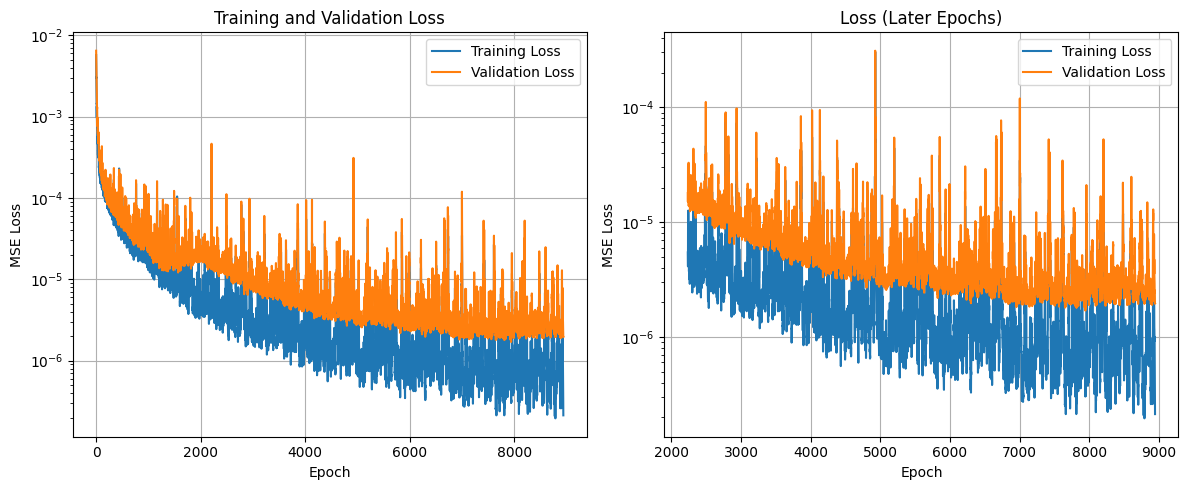

Training completed after 8944 epochs
Best validation loss: 0.000002
Final training loss: 0.000000
Final validation loss: 0.000002


In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(training_results['train_losses'], label='Training Loss')
plt.plot(training_results['val_losses'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
start_epoch = max(0, len(training_results['train_losses']) // 4) 
plt.plot(range(start_epoch, len(training_results['train_losses'])), 
         training_results['train_losses'][start_epoch:], label='Training Loss')
plt.plot(range(start_epoch, len(training_results['val_losses'])), 
         training_results['val_losses'][start_epoch:], label='Validation Loss')
plt.title('Loss (Later Epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Training completed after {training_results['epochs_trained']} epochs")
print(f"Best validation loss: {training_results['best_val_loss']:.6f}")
print(f"Final training loss: {training_results['train_losses'][-1]:.6f}")
print(f"Final validation loss: {training_results['val_losses'][-1]:.6f}")

In [23]:
def plot_model_outputs_at_timepoint(model, target_timepoint, num_samples=None, figsize=(12, 8)):
    """
    Plot the outputs of the trained NN casting all entries at timepoint 0 to an arbitrary target timepoint
    
    Args:
        model: Trained MLP model
        target_timepoint: Target timepoint to cast to (can be any float value)
        num_samples: Number of samples to plot (None for all 1000 samples)
        figsize: Figure size for the plot
    """
    model.eval()
    
    if num_samples is None:
        num_samples = reacher_data[0].shape[0]  # Use all samples
    else:
        num_samples = min(num_samples, reacher_data[0].shape[0])

    with torch.no_grad():
        # Get input data from timepoint 0
        x_input = reacher_data[0][:num_samples, :2]  # First 2 entries [N, 2]
        cond_input = reacher_data[0][:num_samples, 2:]  # Remaining 11 entries [N, 11]

        # Create time tensor for target timepoint
        t_input = torch.full((num_samples, 1), float(target_timepoint), device=device)
        
        # Get model predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Convert to numpy for plotting
        predictions_np = predictions.cpu().numpy()
        
        # Create single plot of predicted distribution
        plt.figure(figsize=(8, 6))
        plt.scatter(predictions_np[:, 0], predictions_np[:, 1], alpha=0.6, s=20, c='red')
        plt.xlabel('Predicted x[0]')
        plt.ylabel('Predicted x[1]')
        plt.title(f'Predicted Distribution at t={target_timepoint}')
        plt.xlim(-1.1,1.1)
        plt.ylim(-1.1,1.1)
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Print some statistics
        print(f"Statistics for {num_samples} samples at t={target_timepoint}:")
        print(f"Predicted range - x[0]: [{predictions_np[:, 0].min():.3f}, {predictions_np[:, 0].max():.3f}], "
              f"x[1]: [{predictions_np[:, 1].min():.3f}, {predictions_np[:, 1].max():.3f}]")
        
        return predictions_np

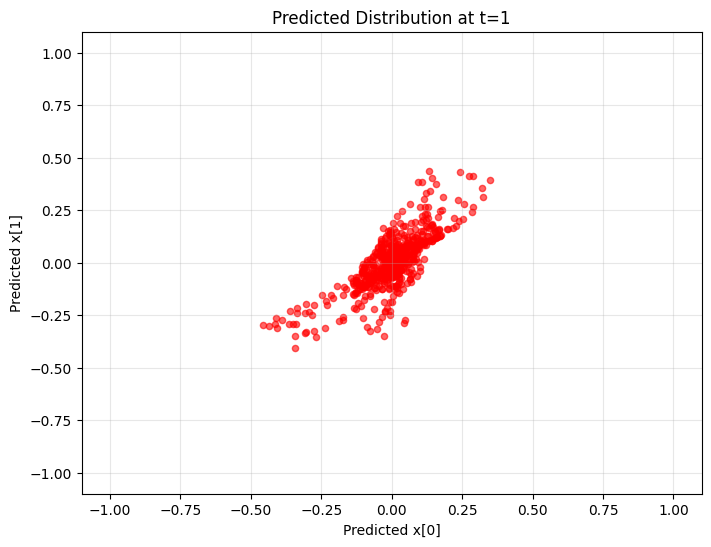

Statistics for 1000 samples at t=1:
Predicted range - x[0]: [-0.457, 0.349], x[1]: [-0.408, 0.437]


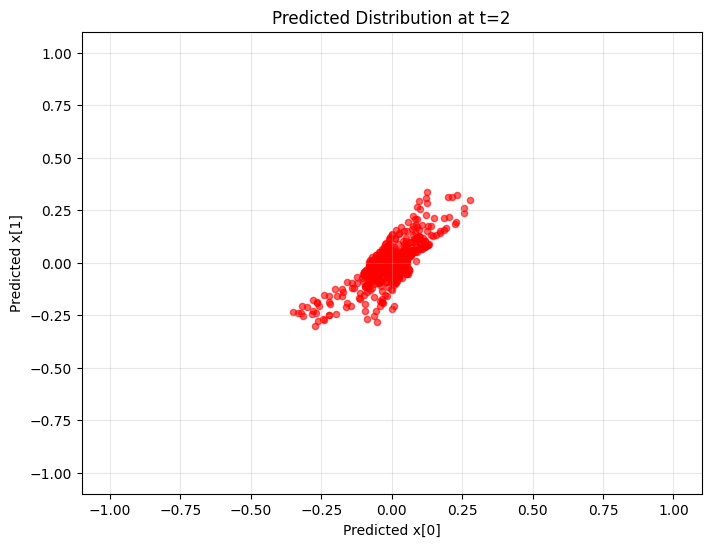

Statistics for 1000 samples at t=2:
Predicted range - x[0]: [-0.349, 0.280], x[1]: [-0.300, 0.335]


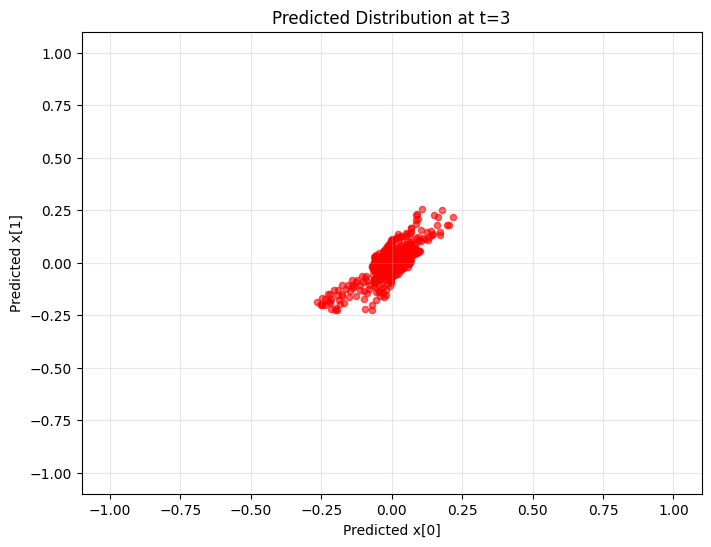

Statistics for 1000 samples at t=3:
Predicted range - x[0]: [-0.263, 0.218], x[1]: [-0.226, 0.256]


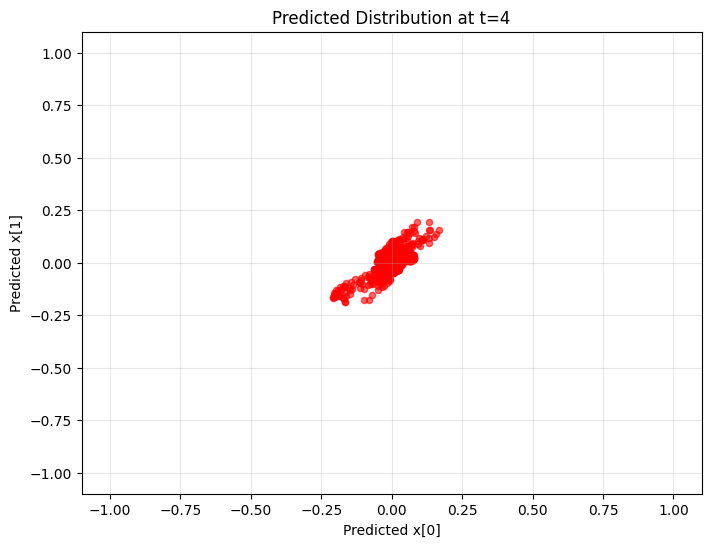

Statistics for 1000 samples at t=4:
Predicted range - x[0]: [-0.209, 0.167], x[1]: [-0.188, 0.194]


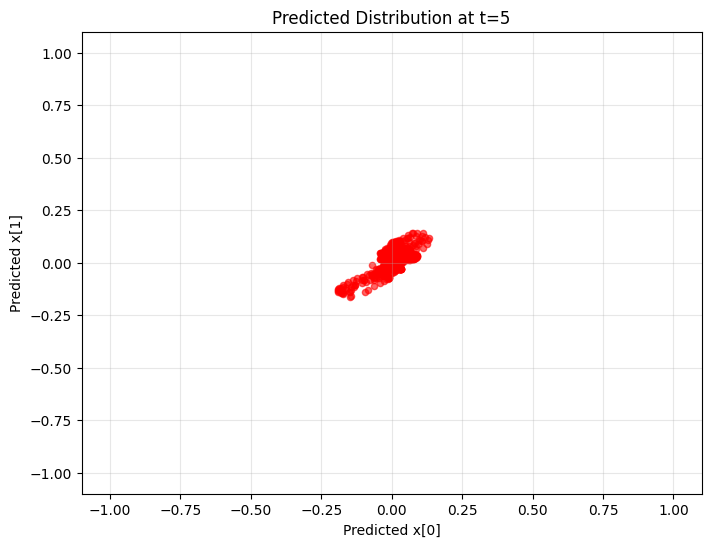

Statistics for 1000 samples at t=5:
Predicted range - x[0]: [-0.191, 0.131], x[1]: [-0.161, 0.143]


array([[-0.14289998, -0.1579027 ],
       [-0.1452744 , -0.13179782],
       [-0.12853785, -0.10484348],
       ...,
       [ 0.01451935, -0.00943528],
       [ 0.01431396, -0.0093756 ],
       [ 0.01409302, -0.00934615]], dtype=float32)

In [24]:
plot_model_outputs_at_timepoint(reacher_model, target_timepoint=1, num_samples=1000)
plot_model_outputs_at_timepoint(reacher_model, target_timepoint=2, num_samples=1000)
plot_model_outputs_at_timepoint(reacher_model, target_timepoint=3, num_samples=1000)
plot_model_outputs_at_timepoint(reacher_model, target_timepoint=4, num_samples=1000)
plot_model_outputs_at_timepoint(reacher_model, target_timepoint=5, num_samples=1000)

# ETT forecasting

In [29]:
def ett_data_gen():
    """
    Loads the ETT forecast dataset.
    """
    data = torch.load("../robustness/ett_forecasts_more_noise.pt")
    data = data.to(device)
    return data

In [30]:
ett = ett_data_gen()

In [31]:
ett.shape

torch.Size([6, 500, 36])